# Import Libraries

In [13]:
import pandas as pd
import numpy as np

# Load Data

In [14]:
orders = pd.read_csv('Orders.csv')
details = pd.read_csv('Details.csv')

# Merge Data By order ID

In [15]:
df = details.merge(
    orders,
    on="Order ID",
    how="left"
)
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
0,B-25681,1096,658,7,Electronics,Electronic Games,COD,04-06-2018,Bhawna,Madhya Pradesh,Indore
1,B-26055,5729,64,14,Furniture,Chairs,EMI,10-03-2018,Harivansh,Uttar Pradesh,Mathura
2,B-25955,2927,146,8,Furniture,Bookcases,EMI,16-01-2018,Shiva,Maharashtra,Pune
3,B-26093,2847,712,8,Electronics,Printers,Credit Card,27-03-2018,Sarita,Maharashtra,Pune
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card,01-04-2018,Vrinda,Maharashtra,Pune


# Explore Data

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
 7   Order Date    1500 non-null   object
 8   CustomerName  1500 non-null   object
 9   State         1500 non-null   object
 10  City          1500 non-null   object
dtypes: int64(3), object(8)
memory usage: 129.0+ KB


***from data info we show that data contain 1500 rows & 11 Column*** 
***no nulls found in data***

In [17]:
df.duplicated().sum()

np.int64(0)

***no duplicate rows in data***

In [18]:
df.describe()

,Amount,Profit,Quantity
count,1500.000000,1500.00000,1500.000000
mean,291.847333,24.64200,3.743333
std,461.924620,168.55881,2.184942
min,4.000000,-1981.00000,1.000000
25%,47.750000,-12.00000,2.000000
50%,122.000000,8.00000,3.000000
75%,326.250000,38.00000,5.000000
max,5729.000000,1864.00000,14.000000


***from descriptive statistics we found that the average Amount is 291.85 average Profit is 24.64 and average Quantity is 3.74.***

***The median values are 122 for Amount 8 for Profit and 3 for Quantity.***

***Amount and Profit have relatively high variation while Quantity has a smaller spread.***

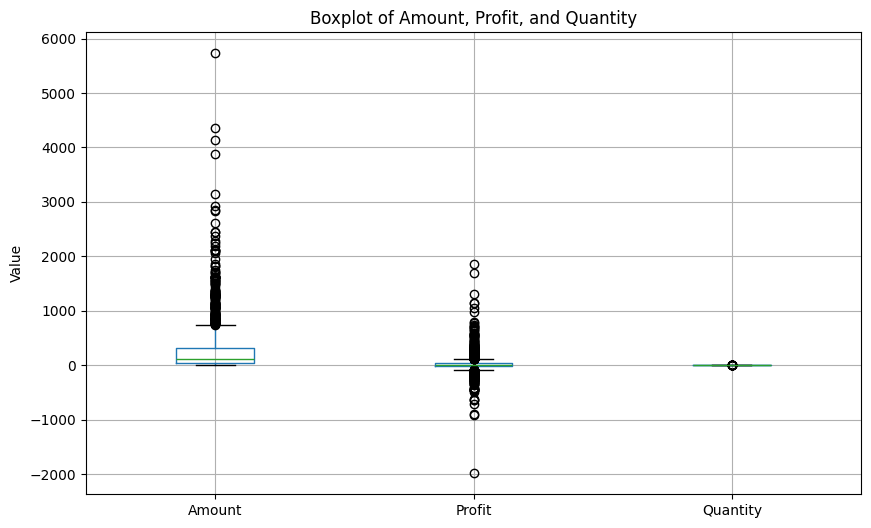

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

df[["Amount", "Profit", "Quantity"]].boxplot()

plt.title("Boxplot of Amount, Profit, and Quantity")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

***from the boxplot we found some extreme values in Amount and Profit.***

***These values were not removed because they may represent real high-value transactions or actual profitable and loss-making orders.***

In [41]:
numeric_cols = [
    "Amount",
    "Profit",
    "Quantity"
]

correlation = df[numeric_cols].corr()

correlation

,Amount,Profit,Quantity
Amount,1.000000,0.309242,0.352486
Profit,0.309242,1.000000,0.063096
Quantity,0.352486,0.063096,1.000000


***from the correlation matrix we found that Amount and Quantity have the strongest correlation (0.352).***

***Amount and Profit have a positive correlation (0.309) while Profit and Quantity have a very weak correlation (0.063).***

***Overall there is no strong correlation between the numerical variables.***

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
 7   Order Date    1500 non-null   object
 8   CustomerName  1500 non-null   object
 9   State         1500 non-null   object
 10  City          1500 non-null   object
dtypes: int64(3), object(8)
memory usage: 129.0+ KB


***all data type are correct except order date***

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   object        
 1   Amount        1500 non-null   int64         
 2   Profit        1500 non-null   int64         
 3   Quantity      1500 non-null   int64         
 4   Category      1500 non-null   object        
 5   Sub-Category  1500 non-null   object        
 6   PaymentMode   1500 non-null   object        
 7   Order Date    1500 non-null   datetime64[ns]
 8   CustomerName  1500 non-null   object        
 9   State         1500 non-null   object        
 10  City          1500 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 129.0+ KB


In [24]:
df['Order ID'].nunique()

500

In [25]:
df[df['Order ID'].duplicated().sort_values(ascending=False)].head(10)

C:\Users\esraa\AppData\Local\Temp\ipykernel_35420\2883767591.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Order ID'].duplicated().sort_values(ascending=False)].head(10)


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
42,B-25681,1625,-77,3,Electronics,Phones,EMI,2018-06-04,Bhawna,Madhya Pradesh,Indore
51,B-25655,74,-123,8,Clothing,Skirt,UPI,2018-05-11,Nida,Madhya Pradesh,Indore
79,B-25735,12,-2,3,Clothing,Hankerchief,COD,2018-07-30,Arindam,Uttar Pradesh,Lucknow
88,B-25853,39,16,6,Clothing,Skirt,UPI,2018-11-08,Gaurav,Gujarat,Ahmedabad
94,B-25957,1157,-13,9,Furniture,Bookcases,Credit Card,2018-01-18,Mahima,Madhya Pradesh,Indore
100,B-25850,93,-1,2,Clothing,Hankerchief,COD,2018-11-05,Abhishek,Goa,Goa
106,B-25730,18,8,2,Clothing,Hankerchief,Debit Card,2018-07-22,Rishabh,Rajasthan,Jaipur
108,B-26067,1120,199,6,Clothing,Saree,EMI,2018-03-16,Tulika,Madhya Pradesh,Bhopal
115,B-25643,1061,-36,8,Furniture,Bookcases,EMI,2018-04-29,Kirti,Jammu and Kashmir,Kashmir
119,B-25752,735,-235,6,Electronics,Printers,COD,2018-08-14,Vaibhav,Madhya Pradesh,Indore


In [26]:
df[df['Order ID']=='B-25681']

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
0,B-25681,1096,658,7,Electronics,Electronic Games,COD,2018-06-04,Bhawna,Madhya Pradesh,Indore
42,B-25681,1625,-77,3,Electronics,Phones,EMI,2018-06-04,Bhawna,Madhya Pradesh,Indore
174,B-25681,523,204,7,Clothing,Trousers,COD,2018-06-04,Bhawna,Madhya Pradesh,Indore
348,B-25681,44,-3,1,Clothing,Saree,Debit Card,2018-06-04,Bhawna,Madhya Pradesh,Indore
370,B-25681,243,-14,2,Furniture,Chairs,COD,2018-06-04,Bhawna,Madhya Pradesh,Indore
1091,B-25681,68,-27,3,Electronics,Accessories,UPI,2018-06-04,Bhawna,Madhya Pradesh,Indore


### Unique Orders Analysis

***only 500 unique Order IDs. This difference is expected because a single order can contain multiple products, categories or sub-categories.***

***Therefore the same Order ID may appear across multiple rows with each row representing a different item or product included in the same order.***

### Statistical Columns are clean

In [27]:
df['Category'].value_counts()

Category
Clothing       949
Electronics    308
Furniture      243
Name: count, dtype: int64

***the column is clean from any different format***

In [28]:
df['Sub-Category'].value_counts()

Sub-Category
Saree               211
Hankerchief         197
Stole               192
Phones               83
Electronic Games     79
Bookcases            79
T-shirt              77
Printers             74
Chairs               74
Furnishings          73
Accessories          72
Shirt                69
Skirt                64
Leggings             53
Kurti                47
Trousers             39
Tables               17
Name: count, dtype: int64

***the column is clean from any different format***

In [29]:
df['PaymentMode'].value_counts()

PaymentMode
COD            684
UPI            331
Debit Card     202
Credit Card    163
EMI            120
Name: count, dtype: int64

***the column is clean from any different format***

In [36]:
df['CustomerName'].sample(10)

189       Vandana
325        Atharv
424       Diwakar
43          Mansi
657        Ashwin
1160      Srishti
968         Aryan
392     Harivansh
1287        Anand
1209        Sonal
Name: CustomerName, dtype: object

In [34]:
df['CustomerName'].value_counts()

CustomerName
Abhishek      21
Priyanka      21
Shreya        18
Shruti        17
Anurag        16
              ..
Shyam          1
Akshata        1
Duhita         1
Utkarsh        1
Inderpreet     1
Name: count, Length: 336, dtype: int64

***from many running samples we show that the columns doesn't contain any format need to be handled***

In [37]:
df['State'].value_counts()

State
Madhya Pradesh       314
Maharashtra          299
Uttar Pradesh         87
Gujarat               87
Delhi                 76
Rajasthan             74
West Bengal           63
Bihar                 62
Punjab                60
Karnataka             50
Jammu and Kashmir     49
Nagaland              45
Kerala                45
Goa                   43
Andhra Pradesh        42
Himachal Pradesh      29
Haryana               26
Tamil Nadu            25
Sikkim                24
Name: count, dtype: int64

***the column is clean from any different format***

In [39]:
df['City'].value_counts()

City
Indore                248
Mumbai                201
Pune                   98
Delhi                  76
Chandigarh             71
Bhopal                 66
Kolkata                63
Ahmedabad              62
Patna                  62
Bangalore              50
Kashmir                49
Thiruvananthapuram     45
Kohima                 45
Jaipur                 44
Goa                    43
Hyderabad              42
Lucknow                38
Mathura                37
Udaipur                30
Simla                  29
Chennai                25
Surat                  25
Gangtok                24
Amritsar               15
Prayagraj              12
Name: count, dtype: int64

***the column is clean from any different format***

***after this checks that we made in data we now can say breifly that data is fully clean***

In [42]:
df.to_csv( 'Sales_data.csv', index=False)